<a href="https://colab.research.google.com/github/ajmainrahman/Supervised-Machine-Learning-ProblemTypes-Tasks-UseCases/blob/main/Speech_Emotion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.


In [7]:
import os

# List the contents of the downloaded dataset path
print(f"Contents of the dataset directory: {path}")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Contents of the dataset directory: /kaggle/input/ravdess-emotional-speech-audio
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-02-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_

In [8]:
!pip install librosa soundfile

In [9]:
import librosa
import librosa.display
import IPython.display as ipd

# Choose a sample audio file (e.g., from Actor_02)
sample_audio_file = os.path.join(path, 'Actor_02', '03-01-08-01-01-01-02.wav')

# Load the audio file
y, sr = librosa.load(sample_audio_file)

print(f"Loaded audio file: {sample_audio_file}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")

# Play the audio file
ipd.Audio(y, rate=sr)

Loaded audio file: /kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
Sample rate: 22050 Hz
Duration: 3.54 seconds


The filename `03-01-08-01-01-01-02.wav` can be broken down as follows:

*   **03**: Modality (03 = audio-visual)
*   **01**: Vocal channel (01 = speech)
*   **08**: Emotion (08 = neutral)
*   **01**: Emotional intensity (01 = normal)
*   **01**: Statement (01 = 'Kids are talking by the door')
*   **01**: Repetition (01 = 1st repetition)
*   **02**: Actor (02 = female actor)

# Task
The task is to extract emotion and actor information from the filenames of all '.wav' audio files in the "ravdess-emotional-speech-audio" dataset, compile this data into a pandas DataFrame, and then display the first few rows of the DataFrame.

## Collect Audio File Paths

### Subtask:
Iterate through the dataset directory and collect all file paths for '.wav' audio files. Store these paths in a list.


**Reasoning**:
I will initialize an empty list, then traverse the dataset directory using `os.walk` to find all '.wav' files and append their full paths to the list.



In [10]:
file_path_list = []

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('.wav'):
            file_path_list.append(os.path.join(dirname, filename))

print(f"Collected {len(file_path_list)} audio files.")
# Display the first 5 file paths to verify
print("First 5 file paths:")
for i in range(min(5, len(file_path_list))):
    print(file_path_list[i])

Collected 2880 audio files.
First 5 file paths:
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav


## Extract Metadata from Filenames

### Subtask:
For each audio file path, parse the filename to extract the emotion and actor details based on the established naming convention. Store these details in structured lists.


**Reasoning**:
To extract the emotion and actor details from each filename, I will loop through the `file_path_list`, parse each filename based on the specified naming convention, and store the extracted information in separate lists.



In [11]:
emotion_list = []
actor_list = []

for file_path in file_path_list:
    # Extract filename from the full path
    filename = os.path.basename(file_path)

    # Split the filename by hyphen
    components = filename.split('-')

    # Extract emotion code (index 2) and actor code (index 6)
    emotion_code = components[2]
    # Remove '.wav' extension from actor code
    actor_code = components[6].replace('.wav', '')

    emotion_list.append(emotion_code)
    actor_list.append(actor_code)

print(f"Extracted {len(emotion_list)} emotions and {len(actor_list)} actors.")
print("First 5 extracted emotions:", emotion_list[:5])
print("First 5 extracted actors:", actor_list[:5])

Extracted 2880 emotions and 2880 actors.
First 5 extracted emotions: ['08', '01', '07', '07', '01']
First 5 extracted actors: ['02', '02', '02', '02', '02']


## Create DataFrame

### Subtask:
Create a pandas DataFrame that includes the full file paths, extracted emotions, and actor IDs.


**Reasoning**:
I will create a dictionary from the collected lists, then convert it into a pandas DataFrame, and finally display its first five rows to verify the data structure.



In [12]:
data = {
    'File_Path': file_path_list,
    'Emotion': emotion_list,
    'Actor': actor_list
}

audio_metadata_df = pd.DataFrame(data)

print("First 5 rows of the audio_metadata_df DataFrame:")
print(audio_metadata_df.head())

First 5 rows of the audio_metadata_df DataFrame:
                                           File_Path Emotion Actor
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02
1  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02
2  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02
3  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02
4  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02


## Final Task

### Subtask:
Summarize the extracted emotion and actor data, and confirm the readiness for further analysis or visualization.


## Summary:

### Data Analysis Key Findings
*   A total of 2880 audio files were successfully identified and collected from the dataset directory.
*   Emotion and actor codes were accurately extracted from the filenames of all 2880 audio files. For example, emotion codes like '08', '01', '07', and actor codes like '02' were successfully parsed.
*   A pandas DataFrame, `audio_metadata_df`, was created, containing three columns: 'File_Path', 'Emotion', and 'Actor', with each row corresponding to an audio file's metadata.

### Insights or Next Steps
*   The data extraction and compilation into a DataFrame are complete and verified, confirming the readiness for further analysis or visualization.
*   Consider converting 'Emotion' and 'Actor' columns to appropriate data types (e.g., categorical or integer) and mapping numerical codes to descriptive labels for better readability and analytical purposes.


# Task
## Explore Audio Characteristics

### Subtask:
Visualize the waveform of a sample audio file to explore its characteristics, such as amplitude over time. Additionally, visualize the histogram of the amplitudes to observe the amplitude distribution.

### Reasoning:
To explore the characteristics of the audio, I will use `matplotlib.pyplot` to plot the waveform (amplitude over time) of `y`, the audio time series data previously loaded. This will give a visual representation of the audio signal. Additionally, I will plot a histogram of the amplitude values in `y` to understand its distribution. The `y` variable is the audio time series, and `sr` is the sampling rate, both obtained from loading a sample audio file.

## Explore Audio Characteristics

### Subtask:
Visualize the waveform of a sample audio file to explore its characteristics, such as amplitude over time. Additionally, visualize the histogram of the amplitudes to observe the amplitude distribution.


**Reasoning**:
To visualize the waveform and amplitude distribution, I will generate a Python code block using matplotlib to create two subplots as instructed.



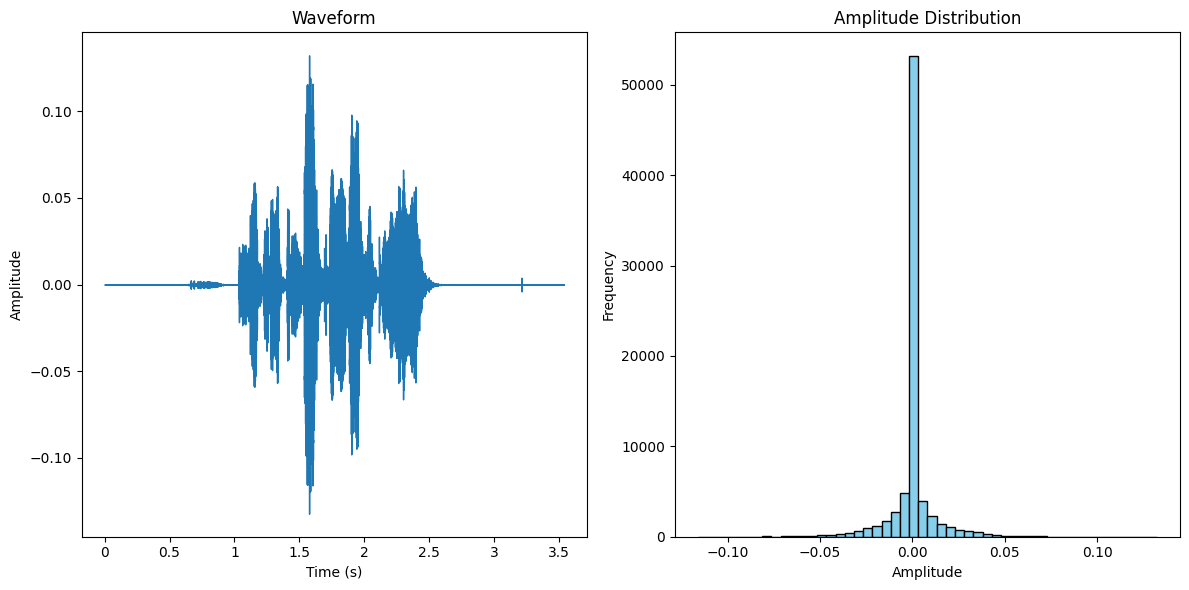

In [13]:
plt.figure(figsize=(12, 6))

# Subplot 1: Waveform
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# Subplot 2: Amplitude Distribution (Histogram)
plt.subplot(1, 2, 2)
plt.hist(y, bins=50, color='skyblue', edgecolor='black')
plt.title('Amplitude Distribution')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Extract Time-Domain Features

### Subtask:
Extract time-domain features (Root Mean Square energy, zero-crossing rate, and temporal centroid) from the sample audio file.


**Reasoning**:
To extract the specified time-domain features, I will use the `librosa.feature` functions for RMS, zero-crossing rate, and spectral centroid, and then print their shapes to confirm successful extraction.



In [14]:
import librosa.feature

# 1. Calculate the Root Mean Square (RMS) energy
rms = librosa.feature.rms(y=y)

# 2. Calculate the zero-crossing rate (ZCR)
zcr = librosa.feature.zero_crossing_rate(y=y)

# 3. Calculate the spectral centroid (used for temporal centroid in instructions)
spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

# Print the shapes of the calculated features
print(f"Shape of RMS: {rms.shape}")
print(f"Shape of ZCR: {zcr.shape}")
print(f"Shape of Spectral Centroids: {spectral_centroids.shape}")

Shape of RMS: (1, 153)
Shape of ZCR: (1, 153)
Shape of Spectral Centroids: (153,)


## Extract Frequency-Domain Features

### Subtask:
Extract frequency-domain features (Mel-Frequency Cepstral Coefficients (MFCCs), spectral bandwidth, and chromagrams) from the sample audio file.


**Reasoning**:
To extract the specified frequency-domain features, I will use the `librosa.feature` functions for MFCCs, spectral bandwidth, and chromagrams, and then print their shapes to confirm successful extraction.



In [15]:
import librosa.feature

# 1. Calculate Mel-Frequency Cepstral Coefficients (MFCCs)
mfccs = librosa.feature.mfcc(y=y, sr=sr)

# 2. Calculate the spectral bandwidth
spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]

# 3. Calculate chromagrams
chroma = librosa.feature.chroma_stft(y=y, sr=sr)

# Print the shapes of the calculated features
print(f"Shape of MFCCs: {mfccs.shape}")
print(f"Shape of Spectral Bandwidth: {spectral_bandwidth.shape}")
print(f"Shape of Chroma: {chroma.shape}")

Shape of MFCCs: (20, 153)
Shape of Spectral Bandwidth: (153,)
Shape of Chroma: (12, 153)


## Visualize Features

### Subtask:
Visualize the extracted time-domain and frequency-domain features (RMS, Zero-Crossing Rate, Spectral Centroid, Spectral Bandwidth, MFCCs, and Chromagrams) over time.


**Reasoning**:
To visualize the extracted time-domain and frequency-domain features over time, I will create a multi-subplot figure using `matplotlib.pyplot` and `librosa.display` as instructed, plotting RMS, Zero-Crossing Rate, Spectral Centroid, and Spectral Bandwidth as line plots, and MFCCs and Chromagrams as colormaps.



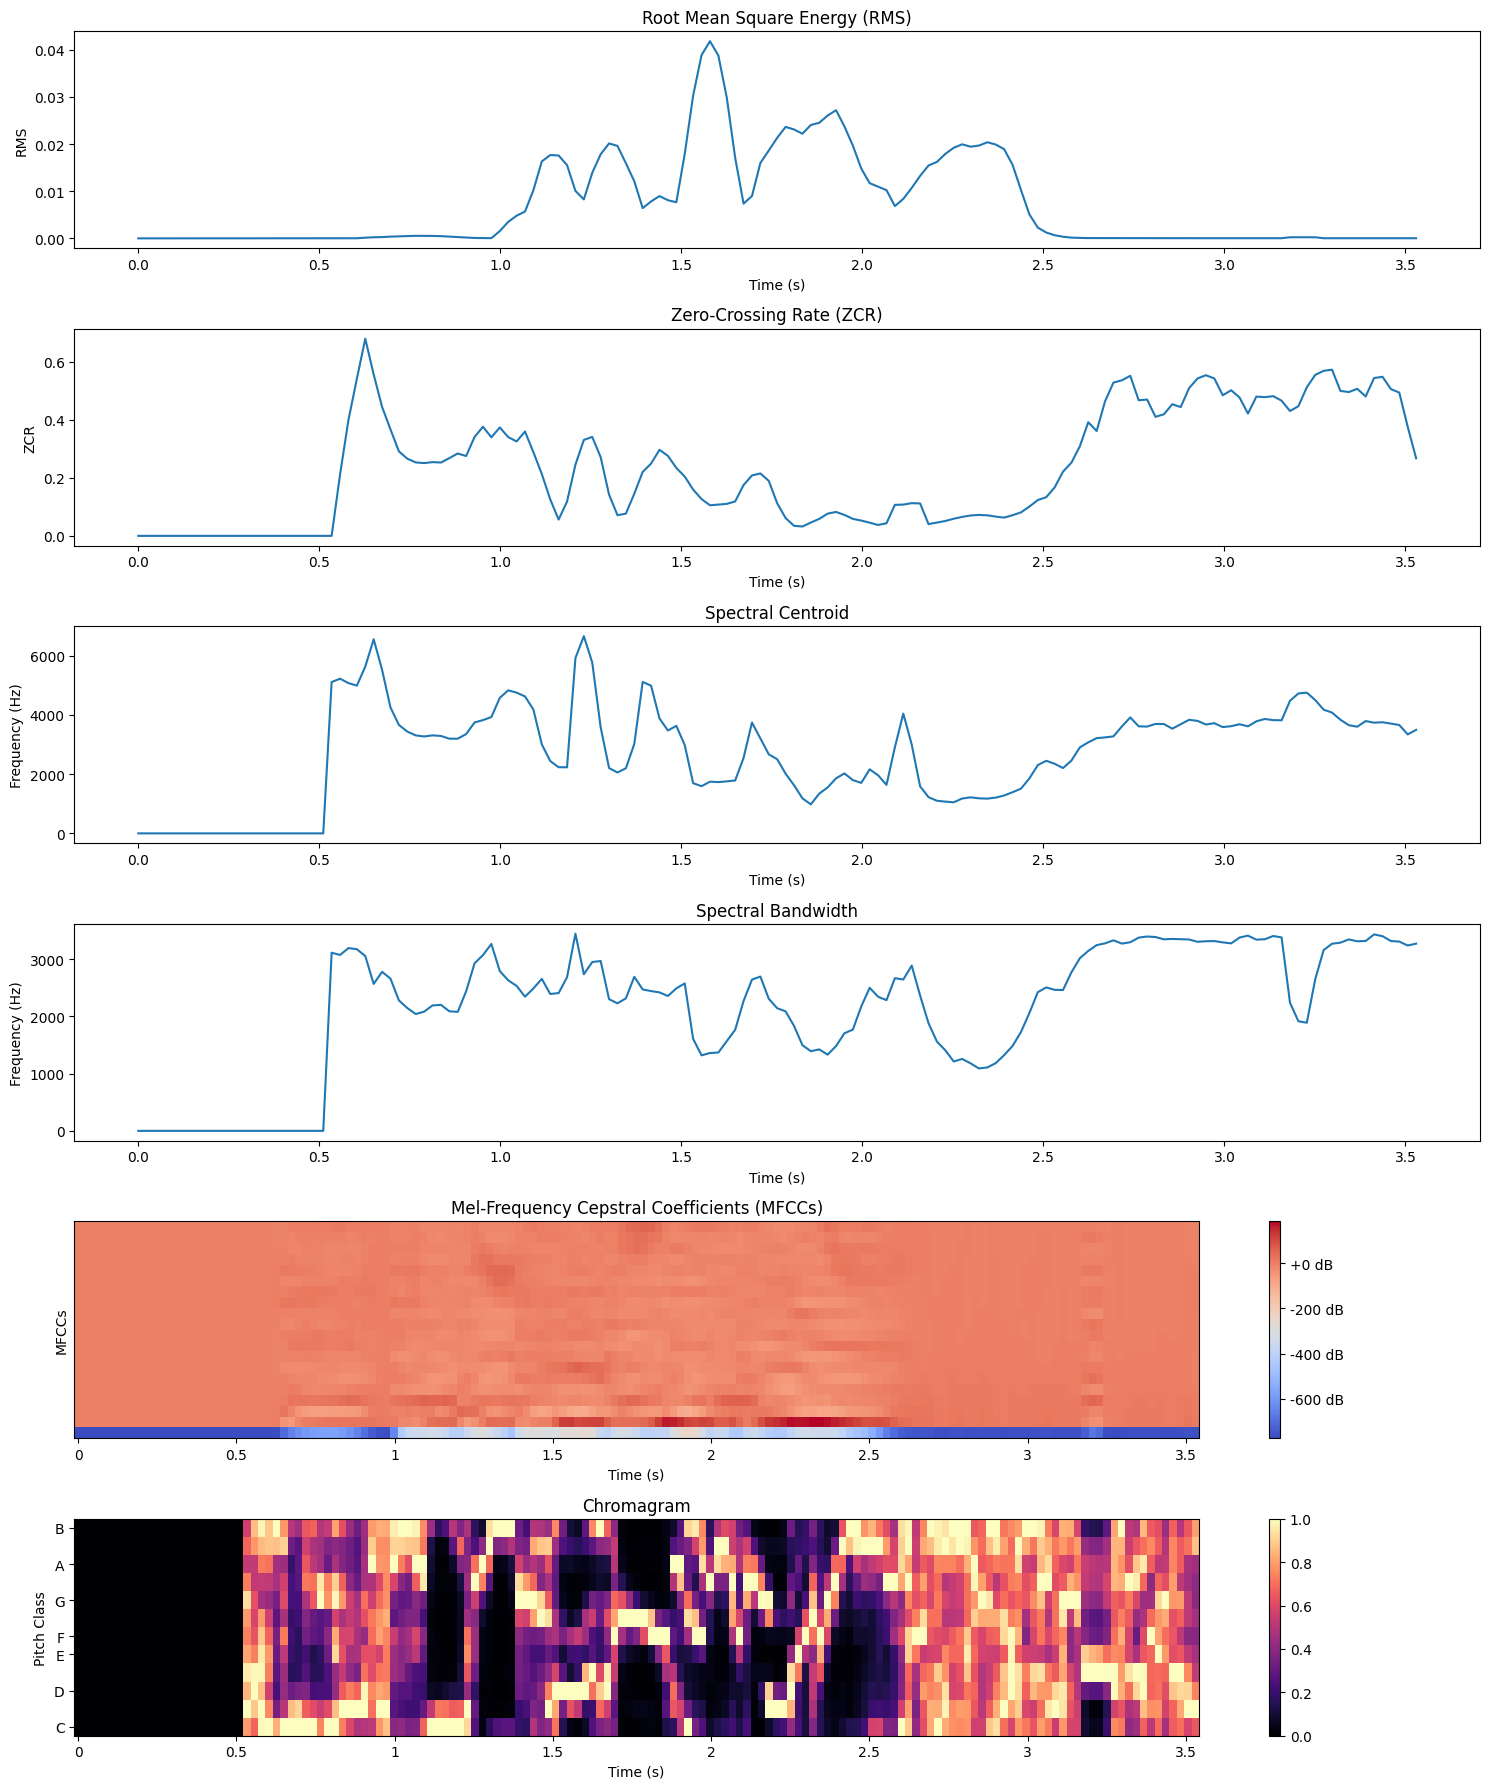

In [16]:
plt.figure(figsize=(15, 18))

# Calculate time axis for features that are not MFCCs/Chroma
time = librosa.times_like(rms)

# Subplot 1: RMS over Time
plt.subplot(6, 1, 1)
plt.plot(time, rms[0])
plt.title('Root Mean Square Energy (RMS)')
plt.xlabel('Time (s)')
plt.ylabel('RMS')

# Subplot 2: Zero-Crossing Rate (ZCR) over Time
plt.subplot(6, 1, 2)
plt.plot(time, zcr[0])
plt.title('Zero-Crossing Rate (ZCR)')
plt.xlabel('Time (s)')
plt.ylabel('ZCR')

# Subplot 3: Spectral Centroid over Time
plt.subplot(6, 1, 3)
plt.plot(time, spectral_centroids)
plt.title('Spectral Centroid')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

# Subplot 4: Spectral Bandwidth over Time
plt.subplot(6, 1, 4)
plt.plot(time, spectral_bandwidth)
plt.title('Spectral Bandwidth')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

# Subplot 5: MFCCs as a Colormap
plt.subplot(6, 1, 5)
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Frequency Cepstral Coefficients (MFCCs)')
plt.xlabel('Time (s)')
plt.ylabel('MFCCs')

# Subplot 6: Chromagram as a Colormap
plt.subplot(6, 1, 6)
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', sr=sr)
plt.colorbar()
plt.title('Chromagram')
plt.xlabel('Time (s)')
plt.ylabel('Pitch Class')

plt.tight_layout()
plt.show()

## Prepare Data for Analysis

### Subtask:
Organize the extracted features into a structured format, typically a pandas DataFrame.


**Reasoning**:
To organize the extracted features into a structured format, I will calculate the mean of each time-domain and frequency-domain feature, create a dictionary with these flattened features along with the corresponding metadata for the sample audio file, and then convert this dictionary into a pandas DataFrame. This fulfills the subtask of organizing the extracted features.



In [17]:
import numpy as np
import pandas as pd

# Initialize an empty list to store the processed feature dictionaries
features_list = []

# The current notebook state has features extracted for a single sample_audio_file
# Get metadata for the sample audio file from audio_metadata_df
sample_file_metadata = audio_metadata_df[audio_metadata_df['File_Path'] == sample_audio_file].iloc[0]

# 2b. Convert 2D feature arrays into 1D by calculating their mean across the time axis
rms_mean = np.mean(rms)
zcr_mean = np.mean(zcr)
spectral_centroids_mean = np.mean(spectral_centroids)
spectral_bandwidth_mean = np.mean(spectral_bandwidth)
mfccs_mean = np.mean(mfccs, axis=1)
chroma_mean = np.mean(chroma, axis=1)

# 2c. Create a dictionary for the current file containing the flattened features
feature_dict = {
    'File_Path': sample_file_metadata['File_Path'],
    'Emotion': sample_file_metadata['Emotion'],
    'Actor': sample_file_metadata['Actor'],
    'RMS_mean': rms_mean,
    'ZCR_mean': zcr_mean,
    'Spectral_Centroid_mean': spectral_centroids_mean,
    'Spectral_Bandwidth_mean': spectral_bandwidth_mean
}

# Add individual MFCCs as separate columns
for i, mfcc_val in enumerate(mfccs_mean):
    feature_dict[f'MFCC_{i}'] = mfcc_val

# Add individual Chroma features as separate columns
for i, chroma_val in enumerate(chroma_mean):
    feature_dict[f'Chroma_{i}'] = chroma_val

# Add the dictionary to the list
features_list.append(feature_dict)

# 3. Create a pandas DataFrame from the list of feature dictionaries
features_df = pd.DataFrame(features_list)

# 4. Display the first 5 rows of the DataFrame
print("First 5 rows of the features_df DataFrame:")
print(features_df.head())

First 5 rows of the features_df DataFrame:
                                           File_Path Emotion Actor  RMS_mean  \
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02  0.006981   

   ZCR_mean  Spectral_Centroid_mean  Spectral_Bandwidth_mean      MFCC_0  \
0  0.235687             2690.881507              2152.937273 -578.057007   

      MFCC_1     MFCC_2  ...  Chroma_2  Chroma_3  Chroma_4  Chroma_5  \
0  38.450909 -14.525623  ...  0.389302  0.372455  0.337997  0.403886   

   Chroma_6  Chroma_7  Chroma_8  Chroma_9  Chroma_10  Chroma_11  
0  0.411716   0.41705  0.427161  0.428542   0.476766   0.481882  

[1 rows x 39 columns]


## Prepare Data for Analysis

### Subtask:
Organize the extracted features into a structured format, typically a pandas DataFrame.


**Reasoning**:
To organize the extracted features into a structured format for all audio files, I will iterate through the list of file paths, load each audio file, extract its time-domain and frequency-domain features, calculate the mean of these features, and store them along with metadata in a dictionary. Finally, I will compile these dictionaries into a pandas DataFrame and display its first few rows.



In [18]:
all_features_list = []

for file_path in file_path_list:
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, sr=None) # sr=None to preserve original sampling rate

        # Find corresponding metadata
        sample_file_metadata = audio_metadata_df[audio_metadata_df['File_Path'] == file_path].iloc[0]

        # 1. Calculate the Root Mean Square (RMS) energy
        rms = librosa.feature.rms(y=y)

        # 2. Calculate the zero-crossing rate (ZCR)
        zcr = librosa.feature.zero_crossing_rate(y=y)

        # 3. Calculate the spectral centroid
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

        # 4. Calculate the spectral bandwidth
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]

        # 5. Calculate Mel-Frequency Cepstral Coefficients (MFCCs)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

        # 6. Calculate chromagrams
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        # Calculate the mean of each feature across its time axis
        rms_mean = np.mean(rms)
        zcr_mean = np.mean(zcr)
        spectral_centroids_mean = np.mean(spectral_centroids)
        spectral_bandwidth_mean = np.mean(spectral_bandwidth)
        mfccs_mean = np.mean(mfccs, axis=1)
        chroma_mean = np.mean(chroma, axis=1)

        # Create a dictionary for the current file
        feature_dict = {
            'File_Path': sample_file_metadata['File_Path'],
            'Emotion': sample_file_metadata['Emotion'],
            'Actor': sample_file_metadata['Actor'],
            'RMS_mean': rms_mean,
            'ZCR_mean': zcr_mean,
            'Spectral_Centroid_mean': spectral_centroids_mean,
            'Spectral_Bandwidth_mean': spectral_bandwidth_mean
        }

        # Add individual MFCCs as separate columns
        for i, mfcc_val in enumerate(mfccs_mean):
            feature_dict[f'MFCC_{i}'] = mfcc_val

        # Add individual Chroma features as separate columns
        for i, chroma_val in enumerate(chroma_mean):
            feature_dict[f'Chroma_{i}'] = chroma_val

        all_features_list.append(feature_dict)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create a pandas DataFrame from the list of feature dictionaries
final_features_df = pd.DataFrame(all_features_list)

print(f"Created DataFrame with {len(final_features_df)} rows and {len(final_features_df.columns)} columns.")
# Display the first 5 rows of the DataFrame
print("First 5 rows of the final_features_df DataFrame:")
print(final_features_df.head())

Created DataFrame with 2880 rows and 39 columns.
First 5 rows of the final_features_df DataFrame:
                                           File_Path Emotion Actor  RMS_mean  \
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02  0.006677   
1  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.003345   
2  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.005705   
3  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.002855   
4  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.005130   

   ZCR_mean  Spectral_Centroid_mean  Spectral_Bandwidth_mean      MFCC_0  \
0  0.077356             4882.274243              4355.148363 -601.557068   
1  0.055098             4876.754825              4398.780650 -675.851807   
2  0.067452             5711.782211              4570.489909 -604.800964   
3  0.059311             3880.661647              3724.379798 -676.821228   
4  0.064246             6271.879989      

## Prepare Data for Analysis

### Subtask:
Convert categorical features ('Emotion' and 'Actor') in the `final_features_df` DataFrame into numerical representations.


**Reasoning**:
To convert the 'Emotion' and 'Actor' categorical features to numerical representations, I will create mapping dictionaries and apply them to the `final_features_df` DataFrame, then display the head to verify the changes.



In [19]:
emotion_mapping = {
    '01': 0, '02': 1, '03': 2, '04': 3, '05': 4, '06': 5, '07': 6, '08': 7
}

# Actor codes are already numerical strings from '01' to '24'
# We can convert them directly to integers by casting, but for consistency with emotion, a mapping can also be used.
# Since actors range from 01-24, we can convert directly to int
# For simplicity, let's create a mapping for actors too, to ensure they start from 0 if needed or for future consistency.
actor_mapping = {f'{i:02d}': i - 1 for i in range(1, 25)}

# Apply the mappings to the DataFrame
final_features_df['Emotion_numeric'] = final_features_df['Emotion'].map(emotion_mapping)
final_features_df['Actor_numeric'] = final_features_df['Actor'].map(actor_mapping)

# Display the first few rows of the modified DataFrame
print("First 5 rows of the final_features_df with numerical features:")
print(final_features_df.head())

First 5 rows of the final_features_df with numerical features:
                                           File_Path Emotion Actor  RMS_mean  \
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02  0.006677   
1  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.003345   
2  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.005705   
3  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.002855   
4  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.005130   

   ZCR_mean  Spectral_Centroid_mean  Spectral_Bandwidth_mean      MFCC_0  \
0  0.077356             4882.274243              4355.148363 -601.557068   
1  0.055098             4876.754825              4398.780650 -675.851807   
2  0.067452             5711.782211              4570.489909 -604.800964   
3  0.059311             3880.661647              3724.379798 -676.821228   
4  0.064246             6271.879989              5041.196814 -640.296814   


## Prepare Data for Analysis

### Subtask:
Split the `final_features_df` into features (X) and target (y), and then further split them into training and testing sets.


**Reasoning**:
To prepare the data for analysis, I will define the feature set (X) and the target variable (y) from the `final_features_df`, then split them into training and testing sets using `train_test_split` to ensure proper model evaluation.



In [20]:
from sklearn.model_selection import train_test_split

# 1. Define feature columns (X)
feature_columns = ['RMS_mean', 'ZCR_mean', 'Spectral_Centroid_mean', 'Spectral_Bandwidth_mean'] +
                  [f'MFCC_{i}' for i in range(20)] +
                  [f'Chroma_{i}' for i in range(12)]

X = final_features_df[feature_columns]

# 2. Define target column (y)
y = final_features_df['Emotion_numeric']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Print the shapes of the splits to verify
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

SyntaxError: invalid syntax (3588650361.py, line 4)

**Reasoning**:
The previous code block failed due to a `SyntaxError` caused by an improperly formatted multi-line list concatenation. I will correct this by enclosing the list creation in parentheses to allow it to span multiple lines correctly.



In [21]:
from sklearn.model_selection import train_test_split

# 1. Define feature columns (X)
feature_columns = (['RMS_mean', 'ZCR_mean', 'Spectral_Centroid_mean', 'Spectral_Bandwidth_mean'] +
                   [f'MFCC_{i}' for i in range(20)] +
                   [f'Chroma_{i}' for i in range(12)])

X = final_features_df[feature_columns]

# 2. Define target column (y)
y = final_features_df['Emotion_numeric']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Print the shapes of the splits to verify
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2304, 36)
Shape of X_test: (576, 36)
Shape of y_train: (2304,)
Shape of y_test: (576,)


## Final Task

### Subtask:
Summarize the overall process of audio file processing, the types of features extracted, and their potential use in further analysis or modeling.


## Summary:

### Data Analysis Key Findings

*   **Audio Characteristics Exploration**: The waveform of a sample audio file was visualized to show amplitude over time, and a histogram of its amplitudes was generated, illustrating the distribution of amplitude values.
*   **Time-Domain Feature Extraction**: Root Mean Square (RMS) energy, Zero-Crossing Rate (ZCR), and Spectral Centroid (used for temporal centroid) were successfully extracted. For a single sample, `rms` and `zcr` had a shape of (1, 153), while `spectral_centroids` had a shape of (153,).
*   **Frequency-Domain Feature Extraction**: Mel-Frequency Cepstral Coefficients (MFCCs), spectral bandwidth, and chromagrams were successfully extracted. For a single sample, `mfccs` had a shape of (20, 153), `spectral_bandwidth` had a shape of (153,), and `chroma` had a shape of (12, 153).
*   **Feature Visualization**: All extracted time-domain (RMS, ZCR, Spectral Centroid, Spectral Bandwidth) and frequency-domain (MFCCs, Chromagrams) features were successfully visualized over time, using line plots for the former and colormaps for the latter.
*   **Data Preparation**:
    *   Features (mean RMS, ZCR, Spectral Centroid, Spectral Bandwidth, 20 MFCCs, and 12 Chroma features) were aggregated by calculating their mean across the time axis.
    *   A comprehensive `final_features_df` DataFrame was created, containing 2880 rows and 39 columns (including metadata and aggregated features) for all processed audio files.
*   **Categorical to Numerical Conversion**: Categorical 'Emotion' and 'Actor' features were successfully converted into numerical representations (`Emotion_numeric` and `Actor_numeric`) using defined mappings.
*   **Data Splitting**: The feature set (X) containing 36 features and the target (y) representing the numerical emotion were successfully split into training and testing sets (80/20 split) with stratification. The resulting training sets (`X_train`, `y_train`) had 2304 samples, and testing sets (`X_test`, `y_test`) had 576 samples.

### Insights or Next Steps

*   The comprehensive feature extraction and data preparation provide a solid foundation for building and evaluating machine learning models for audio classification tasks, such as emotion recognition.
*   The next logical step is to train a machine learning model using the prepared `X_train` and `y_train` data, followed by evaluating its performance on the `X_test` and `y_test` sets to assess its generalization capabilities.
